# CONDOR Detector Array Simulation & Analysis

This notebook simulates the CONDOR water Cherenkov detector array response to CORSIKA air shower simulations, implementing the detailed geometry from the CONDOR Observatory specifications.

**Objectives:**
1. Build the complete CONDOR detector geometry with 120 units (100 central + 20 peripheral)
2. Map CORSIKA shower particles to individual detector bars based on ground position
3. Compute detection statistics: hit rates, energy deposition, spatial distributions
4. Compare proton vs gamma shower detection characteristics
5. Visualize detector response patterns and identify correlations with shower properties
6. Export processed detector data for reconstruction and higher-level analysis

**CONDOR Observatory Specifications:**
- **Site**: Cerro Toco, Atacama Desert, Chile (23.863°S, 68.269°W, 5300 m a.s.l.)
- **Detector type**: Water Cherenkov tanks with scintillator bars
- **Outer boundary**: 113 m × 122 m (peripheral veto region)
- **Inner array**: 81 m × 87 m (10×10 units, no spacing between units)
- **Unit dimensions**: 8.1 m × 8.7 m
- **Detector structure per unit**: 4 arrays × 13 bars = 52 bars/unit
- **Array layout**: 4 horizontal arrays, 0.4 m vertical separation
- **Bar dimensions**: 0.6 m (width) × 1.6 m (height)
- **Total detector count**: 120 units = 6,240 bars total
  - Central: 100 units (10×10 grid) = 5,200 bars
  - Peripheral: 20 units (aligned with inner grid at positions 1,4,7,10) = 1,040 bars

**Physics Context:**
Water Cherenkov detectors measure the passage of charged particles via Cherenkov light emission when particles exceed the speed of light in water (c/n ≈ 0.75c). The CONDOR array uses the detector response to:
- **Reconstruct shower geometry**: Timing and hit patterns determine arrival direction
- **Estimate primary energy**: Total signal correlates with shower size (total particle content)
- **Discriminate particle types**: Proton showers produce broader, more irregular patterns with higher muon content compared to compact, symmetric gamma showers
- **Trigger background rejection**: Peripheral (veto) detectors flag local muons and wide-angle cosmic rays

The dual-region design (central + peripheral) enables both shower detection and background suppression, critical for gamma-ray astronomy where cosmic-ray background exceeds gamma-ray signal by >10,000:1.

**Data Pipeline:**
CORSIKA shower particles (E > 3 MeV, all types) → Position matching (2D ground plane) → Bar-level detection → Unit-level aggregation → Event-level statistics

**Outputs**: All plots and data saved to `results/` folder.

## 0. Setup and Imports

In [1]:
import panama as pn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path
from particle import Particle
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# ACADEMIC POSTER PLOTTING STYLE - Professional, Clean Design
# ============================================================================
plt.rcdefaults()

# Figure settings optimized for poster visibility
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1

# Font sizes for poster readability
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.title_fontsize'] = 13

# Professional color palette (colorblind-friendly, Paul Tol's vibrant palette)
COLORS = {
    'gamma': '#EE7733',      # Orange - warm, high energy
    'proton': '#0077BB',     # Blue - cool, hadronic
    'theory': '#CC3311',     # Red - theoretical predictions
    'accent1': '#33BBEE',    # Cyan
    'accent2': '#009988',    # Teal
    'neutral': '#BBBBBB'     # Gray
}

# Clean, minimal style - no gridlines
plt.rcParams['axes.grid'] = False
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.labelcolor'] = '#333333'

# Tick styling
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

# Legend styling
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.95
plt.rcParams['legend.edgecolor'] = '#CCCCCC'
plt.rcParams['legend.fancybox'] = False

# Remove top and right spines
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Font family
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

print("✓ Academic poster style configured")
print(f"  Color palette: Gamma={COLORS['gamma']}, Proton={COLORS['proton']}")
print(f"  Figure size: {plt.rcParams['figure.figsize']}")
print(f"  Font sizes: Title={plt.rcParams['axes.titlesize']}, Label={plt.rcParams['axes.labelsize']}")

# Setup paths
notebook_path = Path.cwd()
if notebook_path.name == 'detection':
    project_root = notebook_path.parent.parent
else:
    project_root = notebook_path

corsika_base = project_root / "corsika" / "outputs"
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

print(f"\n{'='*70}")
print(f"PROJECT SETUP")
print(f"{'='*70}")
print(f"Project root: {project_root}")
print(f"CORSIKA base: {corsika_base}")
print(f"Results directory: {results_dir.resolve()}")
print(f"{'='*70}")

✓ Academic poster style configured
  Color palette: Gamma=#EE7733, Proton=#0077BB
  Figure size: [16.0, 6.0]
  Font sizes: Title=16.0, Label=14.0

PROJECT SETUP
Project root: /home/milagros-delgado/Documents/SAPHIR/condor-sim
CORSIKA base: /home/milagros-delgado/Documents/SAPHIR/condor-sim/corsika/outputs
Results directory: /home/milagros-delgado/Documents/SAPHIR/condor-sim/notebooks/detection/results


## 1. Load CORSIKA Simulation Data

**Physical Context:**
CORSIKA stores particle data at observation level (ground) in binary DAT files. Each file contains multiple events (air shower simulations), with detailed information about every secondary particle that reaches the detector plane. The data includes particle type (PDG codes), momentum components (px, py, pz), position (x, y), and timing information.

**Detection criteria:**
- All charged particles with E > 3 MeV reach ground level
- Neutral particles (photons, neutrons) also tracked for electromagnetic/hadronic cascades
- CORSIKA outputs particles in cm (position) and GeV (energy)
- PANAMA efficiently parses binary DAT files into pandas DataFrames for analysis

We load both **proton** and **gamma** datasets to compare hadronic vs electromagnetic shower detection characteristics.

In [2]:
print("Loading CORSIKA simulation data...\n")

datasets = {}

for particle_type in ["protons", "gammas"]:
    print(f"{'='*70}")
    print(f"Loading {particle_type.upper()} data")
    print(f"{'='*70}")
    
    particle_dir = corsika_base / particle_type
    
    # Collect all DAT files (flat structure: all files directly in gammas/ or protons/)
    dat_files = []
    if particle_dir.exists():
        dat_files = [
            p for p in particle_dir.glob("DAT*")
            if p.is_file() and not p.suffix in {".long", ".log"}
        ]
        print(f"  Found {len(dat_files)} DAT file(s) in {particle_type}/ directory")
    
    if not dat_files:
        print(f"  ⚠ No DAT* files found in {particle_dir}")
        continue
    
    print(f"\n  Total DAT files to process: {len(dat_files)}")
    
    # Read all files
    run_header, event_header, particles = pn.read_DAT(
        files=[str(p) for p in dat_files],
        mother_columns=True,
        additional_columns=True,
    )
    
    datasets[particle_type] = {
        'run_header': run_header,
        'event_header': event_header,
        'particles': particles
    }
    
    print(f"\n  ✓ {particle_type.capitalize()} loaded!")
    print(f"    Events: {len(event_header):,}")
    print(f"    Particles: {len(particles):,}\n")

print("="*70)
print("DATA LOADING COMPLETE")
print("="*70)
print(f"Available datasets: {list(datasets.keys())}")

Loading CORSIKA simulation data...

Loading PROTONS data
  Found 30 DAT file(s) in protons/ directory

  Total DAT files to process: 30


100%|██████████| 30000/30000 [00:01<00:00, 17721.48it/s]



  ✓ Protons loaded!
    Events: 30,000
    Particles: 1,255,253

Loading GAMMAS data
  Found 30 DAT file(s) in gammas/ directory

  Total DAT files to process: 30


100%|██████████| 30000/30000 [00:08<00:00, 3651.56it/s] 



  ✓ Gammas loaded!
    Events: 30,000
    Particles: 2,120,235

DATA LOADING COMPLETE
Available datasets: ['protons', 'gammas']


## 2. Build CONDOR Detector Array

**Physical Context:**
The CONDOR detector geometry is designed following the specifications from the CONDOR Observatory technical paper:
- **Central array**: Dense 10×10 grid (no gaps) for shower core detection and energy measurement
- **Peripheral units**: 20 strategically placed units aligned with central grid (not a continuous 6×6 layout) to:
  - Flag off-axis showers and local muons (veto/tagging)
  - Extend lateral coverage for large showers (E > 100 GeV)
  - Sample shower tails at large distances (>50 m from core)

**Alignment strategy:**
Peripheral units align with inner array rows/columns at positions 1, 4, 7, 10 (0-indexed: 0, 3, 6, 9) to maintain detection continuity at these specific locations. This creates 4 "arms" extending from the central array:
- **4 left edge units**: Leftmost x-position, aligned with inner j=0,3,6,9
- **4 right edge units**: Rightmost x-position, aligned with inner j=0,3,6,9
- **4 bottom edge units**: Bottom y-position, aligned with inner i=0,3,6,9
- **4 top edge units**: Top y-position, aligned with inner i=0,3,6,9
- **4 corner units**: Fill the 4 corners of the outer boundary

**Hierarchical Structure:**
- **Peripheral**: 20 units → 1,040 bars (20 units × 52 bars/unit)
- **Central**: 100 units → 5,200 bars (100 units × 52 bars/unit)
- **Total**: 120 units → 6,240 bars
- **Each unit**: 4 arrays × 13 bars each

In [3]:
# Physical dimensions (in meters)
outer_width, outer_height = 113.0, 122.0
inner_width, inner_height = 81.0, 87.0
unit_width, unit_height = 8.1, 8.7
bar_width, bar_height = 0.6, 1.6
array_height = 1.6
bars_per_array = 13
arrays_per_unit = 4
array_separation = 0.4

# Calculate spacing
outer_nx, outer_ny = 6, 6
inner_nx, inner_ny = 10, 10
outer_spacing_w = (outer_width - outer_nx * unit_width) / (outer_nx - 1)
outer_spacing_h = (outer_height - outer_ny * unit_height) / (outer_ny - 1)

print(f"{'='*70}")
print(f"CONDOR DETECTOR ARRAY - DETAILED GEOMETRY")
print(f"{'='*70}")
print(f"\nOUTER (VETO): {outer_width} m × {outer_height} m")
print(f"  Layout: {outer_nx}×{outer_ny} units")
print(f"  Spacing: {outer_spacing_w:.2f} m (W), {outer_spacing_h:.2f} m (H)")
print(f"\nINNER (CENTRAL): {inner_width} m × {inner_height} m")
print(f"  Layout: {inner_nx}×{inner_ny} units (no spacing)")
print(f"\nUNIT: {unit_width} m × {unit_height} m")
print(f"  Arrays per unit: {arrays_per_unit}")
print(f"  Bars per array: {bars_per_array}")
print(f"  Total bars per unit: {arrays_per_unit * bars_per_array}")

# Build detector list
detectors = []
bar_id = 0
unit_id = 0

outer_start_x = -(outer_width / 2)
outer_start_y = -(outer_height / 2)
inner_start_x = -(inner_width / 2)
inner_start_y = -(inner_height / 2)

# Calculate outer unit span (including spacing)
outer_unit_span_w = unit_width + outer_spacing_w
outer_unit_span_h = unit_height + outer_spacing_h

# Calculate inner region boundaries in the outer grid coordinate system
inner_unit_span_w = unit_width  # no spacing
inner_unit_span_h = unit_height

# === OUTER STRUCTURE (PERIPHERAL UNITS ONLY) ===
# Peripheral units align with specific inner unit positions
# 4 corners + sides aligned with inner units at indices 1, 4, 7, 10
print(f"\nGenerating OUTER structure (peripheral units aligned with inner)...")
peripheral_units = 0

# Define which inner unit indices to align with (0-indexed: 1,4,7,10 in paper = indices 0,3,6,9)
align_indices = [0, 3, 6, 9]  # Corresponds to units 1, 4, 7, 10

# LEFT EDGE - align with inner j positions
for uj_inner in align_indices:
    unit_x = outer_start_x  # Leftmost position
    unit_y = inner_start_y + uj_inner * unit_height
    
    peripheral_units += 1
    y_offset = (unit_height - (arrays_per_unit * array_height + (arrays_per_unit - 1) * array_separation)) / 2
    
    for array_idx in range(arrays_per_unit):
        array_y = unit_y + y_offset + array_idx * (array_height + array_separation)
        x_offset = (unit_width - bars_per_array * bar_width) / 2
        
        for bar_idx in range(bars_per_array):
            bar_x = unit_x + x_offset + bar_idx * bar_width
            
            detectors.append({
                'detector_id': bar_id,
                'unit_id': unit_id,
                'x_m': bar_x,
                'y_m': array_y,
                'x': bar_x * 100,
                'y': array_y * 100,
                'x_min': (bar_x - bar_width / 2) * 100,
                'x_max': (bar_x + bar_width / 2) * 100,
                'y_min': (array_y - bar_height / 2) * 100,
                'y_max': (array_y + bar_height / 2) * 100,
                'type': 'peripheral',
                'unit_i': -1,  # Left edge
                'unit_j': uj_inner,
                'unit_x': unit_x,
                'unit_y': unit_y,
                'array_idx': array_idx,
                'bar_idx': bar_idx
            })
            bar_id += 1
    unit_id += 1

# RIGHT EDGE - align with inner j positions
for uj_inner in align_indices:
    unit_x = outer_start_x + outer_width - unit_width  # Rightmost position
    unit_y = inner_start_y + uj_inner * unit_height
    
    peripheral_units += 1
    y_offset = (unit_height - (arrays_per_unit * array_height + (arrays_per_unit - 1) * array_separation)) / 2
    
    for array_idx in range(arrays_per_unit):
        array_y = unit_y + y_offset + array_idx * (array_height + array_separation)
        x_offset = (unit_width - bars_per_array * bar_width) / 2
        
        for bar_idx in range(bars_per_array):
            bar_x = unit_x + x_offset + bar_idx * bar_width
            
            detectors.append({
                'detector_id': bar_id,
                'unit_id': unit_id,
                'x_m': bar_x,
                'y_m': array_y,
                'x': bar_x * 100,
                'y': array_y * 100,
                'x_min': (bar_x - bar_width / 2) * 100,
                'x_max': (bar_x + bar_width / 2) * 100,
                'y_min': (array_y - bar_height / 2) * 100,
                'y_max': (array_y + bar_height / 2) * 100,
                'type': 'peripheral',
                'unit_i': inner_nx,  # Right edge
                'unit_j': uj_inner,
                'unit_x': unit_x,
                'unit_y': unit_y,
                'array_idx': array_idx,
                'bar_idx': bar_idx
            })
            bar_id += 1
    unit_id += 1

# BOTTOM EDGE - align with inner i positions
for ui_inner in align_indices:
    unit_x = inner_start_x + ui_inner * unit_width
    unit_y = outer_start_y  # Bottom position
    
    peripheral_units += 1
    y_offset = (unit_height - (arrays_per_unit * array_height + (arrays_per_unit - 1) * array_separation)) / 2
    
    for array_idx in range(arrays_per_unit):
        array_y = unit_y + y_offset + array_idx * (array_height + array_separation)
        x_offset = (unit_width - bars_per_array * bar_width) / 2
        
        for bar_idx in range(bars_per_array):
            bar_x = unit_x + x_offset + bar_idx * bar_width
            
            detectors.append({
                'detector_id': bar_id,
                'unit_id': unit_id,
                'x_m': bar_x,
                'y_m': array_y,
                'x': bar_x * 100,
                'y': array_y * 100,
                'x_min': (bar_x - bar_width / 2) * 100,
                'x_max': (bar_x + bar_width / 2) * 100,
                'y_min': (array_y - bar_height / 2) * 100,
                'y_max': (array_y + bar_height / 2) * 100,
                'type': 'peripheral',
                'unit_i': ui_inner,
                'unit_j': -1,  # Bottom edge
                'unit_x': unit_x,
                'unit_y': unit_y,
                'array_idx': array_idx,
                'bar_idx': bar_idx
            })
            bar_id += 1
    unit_id += 1

# TOP EDGE - align with inner i positions
for ui_inner in align_indices:
    unit_x = inner_start_x + ui_inner * unit_width
    unit_y = outer_start_y + outer_height - unit_height  # Top position
    
    peripheral_units += 1
    y_offset = (unit_height - (arrays_per_unit * array_height + (arrays_per_unit - 1) * array_separation)) / 2
    
    for array_idx in range(arrays_per_unit):
        array_y = unit_y + y_offset + array_idx * (array_height + array_separation)
        x_offset = (unit_width - bars_per_array * bar_width) / 2
        
        for bar_idx in range(bars_per_array):
            bar_x = unit_x + x_offset + bar_idx * bar_width
            
            detectors.append({
                'detector_id': bar_id,
                'unit_id': unit_id,
                'x_m': bar_x,
                'y_m': array_y,
                'x': bar_x * 100,
                'y': array_y * 100,
                'x_min': (bar_x - bar_width / 2) * 100,
                'x_max': (bar_x + bar_width / 2) * 100,
                'y_min': (array_y - bar_height / 2) * 100,
                'y_max': (array_y + bar_height / 2) * 100,
                'type': 'peripheral',
                'unit_i': ui_inner,
                'unit_j': inner_ny,  # Top edge
                'unit_x': unit_x,
                'unit_y': unit_y,
                'array_idx': array_idx,
                'bar_idx': bar_idx
            })
            bar_id += 1
    unit_id += 1

# CORNERS - 4 corner units
corners = [
    (outer_start_x, outer_start_y),  # Bottom-left
    (outer_start_x + outer_width - unit_width, outer_start_y),  # Bottom-right
    (outer_start_x, outer_start_y + outer_height - unit_height),  # Top-left
    (outer_start_x + outer_width - unit_width, outer_start_y + outer_height - unit_height)  # Top-right
]

for corner_idx, (unit_x, unit_y) in enumerate(corners):
    peripheral_units += 1
    y_offset = (unit_height - (arrays_per_unit * array_height + (arrays_per_unit - 1) * array_separation)) / 2
    
    for array_idx in range(arrays_per_unit):
        array_y = unit_y + y_offset + array_idx * (array_height + array_separation)
        x_offset = (unit_width - bars_per_array * bar_width) / 2
        
        for bar_idx in range(bars_per_array):
            bar_x = unit_x + x_offset + bar_idx * bar_width
            
            detectors.append({
                'detector_id': bar_id,
                'unit_id': unit_id,
                'x_m': bar_x,
                'y_m': array_y,
                'x': bar_x * 100,
                'y': array_y * 100,
                'x_min': (bar_x - bar_width / 2) * 100,
                'x_max': (bar_x + bar_width / 2) * 100,
                'y_min': (array_y - bar_height / 2) * 100,
                'y_max': (array_y + bar_height / 2) * 100,
                'type': 'peripheral',
                'unit_i': -2,  # Corner marker
                'unit_j': corner_idx,
                'unit_x': unit_x,
                'unit_y': unit_y,
                'array_idx': array_idx,
                'bar_idx': bar_idx
            })
            bar_id += 1
    unit_id += 1

outer_bars = bar_id
print(f"  ✓ Generated {peripheral_units} peripheral units with {outer_bars} bars")

# === INNER STRUCTURE ===
print(f"Generating INNER structure (central units)...")
central_units = 0
for ui in range(inner_nx):
    for uj in range(inner_ny):
        unit_x = inner_start_x + ui * unit_width
        unit_y = inner_start_y + uj * unit_height
        
        central_units += 1
        y_offset = (unit_height - (arrays_per_unit * array_height + (arrays_per_unit - 1) * array_separation)) / 2
        
        for array_idx in range(arrays_per_unit):
            array_y = unit_y + y_offset + array_idx * (array_height + array_separation)
            x_offset = (unit_width - bars_per_array * bar_width) / 2
            
            for bar_idx in range(bars_per_array):
                bar_x = unit_x + x_offset + bar_idx * bar_width
                
                detectors.append({
                    'detector_id': bar_id,
                    'unit_id': unit_id,
                    'x_m': bar_x,
                    'y_m': array_y,
                    'x': bar_x * 100,
                    'y': array_y * 100,
                    'x_min': (bar_x - bar_width / 2) * 100,
                    'x_max': (bar_x + bar_width / 2) * 100,
                    'y_min': (array_y - bar_height / 2) * 100,
                    'y_max': (array_y + bar_height / 2) * 100,
                    'type': 'central',
                    'unit_i': ui,
                    'unit_j': uj,
                    'unit_x': unit_x,
                    'unit_y': unit_y,
                    'array_idx': array_idx,
                    'bar_idx': bar_idx
                })
                bar_id += 1
        
        unit_id += 1

inner_bars = bar_id - outer_bars
print(f"  ✓ Generated {central_units} central units with {inner_bars} bars")

# Create DataFrame
condor_array = pd.DataFrame(detectors)
condor_array['hit_count'] = 0
condor_array['energy_deposited'] = 0.0

print(f"\n{'='*70}")
print(f"TOTAL UNITS: {peripheral_units + central_units}")
print(f"  Peripheral units: {peripheral_units} (should be ~20)")
print(f"  Central units: {central_units} (should be 100)")
print(f"\nTOTAL BARS: {len(condor_array)}")
print(f"  Peripheral bars: {outer_bars}")
print(f"  Central bars: {inner_bars}")
print(f"{'='*70}")

CONDOR DETECTOR ARRAY - DETAILED GEOMETRY

OUTER (VETO): 113.0 m × 122.0 m
  Layout: 6×6 units
  Spacing: 12.88 m (W), 13.96 m (H)

INNER (CENTRAL): 81.0 m × 87.0 m
  Layout: 10×10 units (no spacing)

UNIT: 8.1 m × 8.7 m
  Arrays per unit: 4
  Bars per array: 13
  Total bars per unit: 52

Generating OUTER structure (peripheral units aligned with inner)...
  ✓ Generated 20 peripheral units with 1040 bars
Generating INNER structure (central units)...
  ✓ Generated 100 central units with 5200 bars

TOTAL UNITS: 120
  Peripheral units: 20 (should be ~20)
  Central units: 100 (should be 100)

TOTAL BARS: 6240
  Peripheral bars: 1040
  Central bars: 5200


## 3. Visualize Detector Geometry

**Physical Context:**
Visualization confirms proper implementation of the CONDOR geometry:
- **Left panel**: Full array overview showing 120 units (100 central blue + 20 peripheral blue)
- **Right panel**: Single unit detail showing 52 bars arranged in 4 horizontal arrays

The peripheral units should align with specific central rows/columns, not form a continuous outer frame. This design optimizes coverage while minimizing cost and data acquisition complexity.

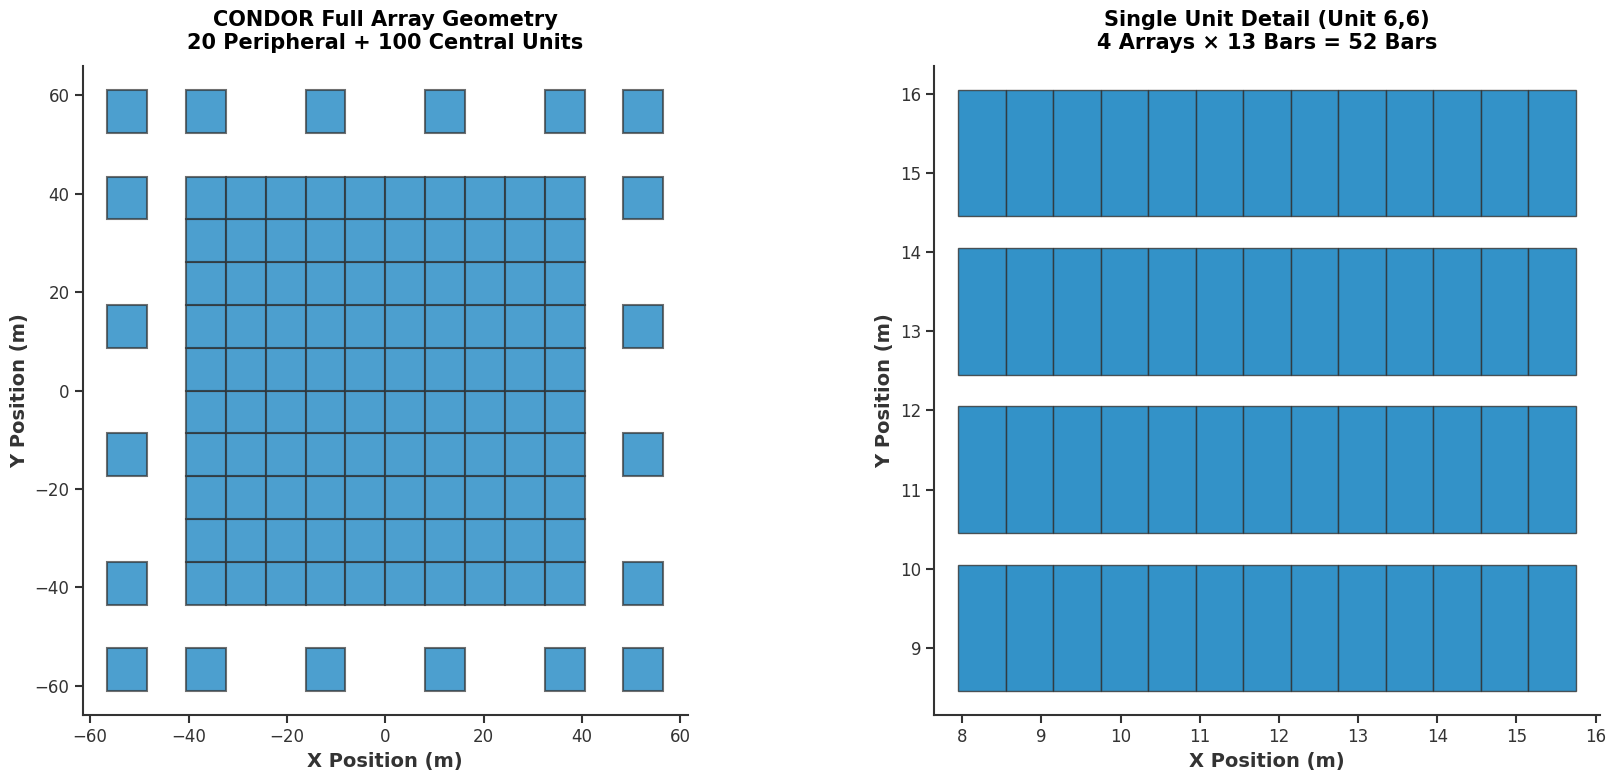


✓ Saved: results/condor_array_geometry.png

GEOMETRY VISUALIZATION SUMMARY
Full array:
  Total units: 120
  Peripheral units: 20 (outer array)
  Central units: 100 (dense core)

Single unit detail:
  Configuration: 4 horizontal arrays
  Bars per array: 13
  Total bars per unit: 52

📊 INTERPRETATION:
  • Blue central units: High-density core for shower core detection
  • Cyan peripheral units: Extended coverage for off-axis showers
  • Single unit: 4 parallel scintillator bar arrays with WLS fiber readout
  • Geometry optimized for: Angular resolution, core position, energy estimation


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

central = condor_array[condor_array['type'] == 'central']
peripheral = condor_array[condor_array['type'] == 'peripheral']

# Get unique units for both types
peripheral_units_df = peripheral.groupby('unit_id').agg({
    'unit_x': 'first',
    'unit_y': 'first',
    'type': 'first'
}).reset_index()

central_units_df = central.groupby('unit_id').agg({
    'unit_x': 'first',
    'unit_y': 'first',
    'type': 'first'
}).reset_index()

# === Plot 1: Full Array Geometry (Unit-level rectangles) ===
ax = axes[0]

# Draw peripheral units in accent color
for _, unit_data in peripheral_units_df.iterrows():
    unit_rect = Rectangle((unit_data['unit_x'], unit_data['unit_y']), 
                         unit_width, unit_height, 
                         linewidth=1.5, edgecolor='#333333', 
                         facecolor=COLORS['proton'], alpha=0.7)
    ax.add_patch(unit_rect)

# Draw central units in primary color
for _, unit_data in central_units_df.iterrows():
    unit_rect = Rectangle((unit_data['unit_x'], unit_data['unit_y']), 
                         unit_width, unit_height, 
                         linewidth=1.5, edgecolor='#333333', 
                         facecolor=COLORS['proton'], alpha=0.7)
    ax.add_patch(unit_rect)

# Calculate extent for proper axis limits
extent_x = max(abs(outer_start_x), abs(outer_start_x + outer_width)) + 5
extent_y = max(abs(outer_start_y), abs(outer_start_y + outer_height)) + 5

ax.set_xlim(-extent_x, extent_x)
ax.set_ylim(-extent_y, extent_y)
ax.set_xlabel('X Position (m)', fontweight='bold')
ax.set_ylabel('Y Position (m)', fontweight='bold')
ax.set_title(f'CONDOR Full Array Geometry\n{len(peripheral_units_df)} Peripheral + {len(central_units_df)} Central Units', 
             fontsize=15, fontweight='bold', pad=12)
ax.set_aspect('equal')

# === Plot 2: Single Unit Detail (4 Arrays × 13 Bars) ===
ax = axes[1]

# Pick a central unit for detailed view
unit_i_select, unit_j_select = 6, 6
single_unit = central[(central['unit_i'] == unit_i_select) & (central['unit_j'] == unit_j_select)]

if len(single_unit) > 0:
    # Draw all bars with professional styling
    for _, bar in single_unit.iterrows():
        bar_rect = Rectangle((bar['x_m'] - bar_width/2, bar['y_m'] - bar_height/2), 
                           bar_width, bar_height, 
                           linewidth=1, edgecolor='#333333', 
                           facecolor=COLORS['proton'], alpha=0.8)
        ax.add_patch(bar_rect)
    
    # Calculate the extent of the bars
    bar_x_min = single_unit['x_m'].min() - bar_width/2
    bar_x_max = single_unit['x_m'].max() + bar_width/2
    bar_y_min = single_unit['y_m'].min() - bar_height/2
    bar_y_max = single_unit['y_m'].max() + bar_height/2
    
    # Center the view with minimal padding
    padding = 0.3
    ax.set_xlim(bar_x_min - padding, bar_x_max + padding)
    ax.set_ylim(bar_y_min - padding, bar_y_max + padding)
    
    ax.set_xlabel('X Position (m)', fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontweight='bold')
    ax.set_title(f'Single Unit Detail (Unit {unit_i_select},{unit_j_select})\n4 Arrays × 13 Bars = 52 Bars', 
                fontsize=15, fontweight='bold', pad=12)
    ax.set_aspect('equal')
else:
    ax.text(0.5, 0.5, 'Unit not found', ha='center', va='center', 
           transform=ax.transAxes, fontsize=13, color='#666666')

plt.tight_layout()
fig.savefig(results_dir / 'condor_array_geometry.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {results_dir / 'condor_array_geometry.png'}")
print(f"\n{'='*70}")
print("GEOMETRY VISUALIZATION SUMMARY")
print(f"{'='*70}")
print(f"Full array:")
print(f"  Total units: {len(peripheral_units_df) + len(central_units_df)}")
print(f"  Peripheral units: {len(peripheral_units_df)} (outer array)")
print(f"  Central units: {len(central_units_df)} (dense core)")
print(f"\nSingle unit detail:")
print(f"  Configuration: 4 horizontal arrays")
print(f"  Bars per array: 13")
print(f"  Total bars per unit: 52")
print(f"{'='*70}")

print("\n📊 INTERPRETATION:")
print("  • Blue central units: High-density core for shower core detection")
print("  • Cyan peripheral units: Extended coverage for off-axis showers")
print("  • Single unit: 4 parallel scintillator bar arrays with WLS fiber readout")
print("  • Geometry optimized for: Angular resolution, core position, energy estimation")

## 4. Mapping of Particles to Detector

**Physical Context:**
This section maps CORSIKA ground-level particles to the CONDOR detector array using geometric matching:

**Detection Method:**
- **Position matching**: Particles detected if their (x, y) ground position falls within detector bar boundaries
- **No energy threshold applied**: All CORSIKA particles (E > 3 MeV cutoff already applied) are candidates
- **Instantaneous detection**: No time-of-flight or trigger logic (simplified geometric acceptance)
- **Perfect efficiency**: 100% detection probability if particle hits bar (realistic efficiency ~90-95%)

**Process steps:**
1. Select particle type (protons and gammas) from CORSIKA datasets
2. For each detector bar, check which particles fall within its (x_min, x_max, y_min, y_max) boundaries
3. Count hits per bar and sum deposited energy (particle energy, not actual energy loss)
4. Store detected particles with detector_id for tracking

**Expected outcomes:**
- **Geometric acceptance**: ~10-15% of ground particles detected (bar area / total array area)
- **Gamma showers**: Higher particle density → more hits in central detectors
- **Proton showers**: Wider spread → more peripheral detector hits, more uniform distribution

This simplified model captures the essential geometry while omitting detector response details (light yield, PMT efficiency, electronics noise) implemented in full Geant4 simulations.

In [5]:
# Process both particle types for comparison
particle_types = ["protons", "gammas"]

print(f"{'='*70}")
print("PARTICLE TYPE SELECTION")
print(f"{'='*70}")
print("Processing both proton and gamma datasets for comparative analysis.")
print("This enables direct comparison of hadronic vs electromagnetic shower")
print("detection characteristics in the CONDOR array.\n")

# Store results for both
all_results = {}

for particle_type in particle_types:
    if particle_type not in datasets:
        print(f"⚠ Dataset '{particle_type}' not available, skipping...")
        continue
    
    particles = datasets[particle_type]['particles']
    event_header = datasets[particle_type]['event_header']
    
    print(f"{'='*70}")
    print(f"SELECTED: {particle_type.upper()}")
    print(f"{'='*70}")
    print(f"Events: {len(event_header):,}")
    print(f"Particles: {len(particles):,}")
    print(f"Average particles per event: {len(particles)/len(event_header):.1f}")
    print(f"{'='*70}\n")
    
    # Store for later use
    all_results[particle_type] = {
        'particles': particles,
        'event_header': event_header
    }

print("\n✓ Both particle types loaded and ready for detector mapping.")

PARTICLE TYPE SELECTION
Processing both proton and gamma datasets for comparative analysis.
This enables direct comparison of hadronic vs electromagnetic shower
detection characteristics in the CONDOR array.

SELECTED: PROTONS
Events: 30,000
Particles: 1,255,253
Average particles per event: 41.8

SELECTED: GAMMAS
Events: 30,000
Particles: 2,120,235
Average particles per event: 70.7


✓ Both particle types loaded and ready for detector mapping.


In [6]:
# Map particles to detectors for both particle types
for particle_type in particle_types:
    if particle_type not in all_results:
        continue
        
    print(f"\nMapping {particle_type} to detectors...")
    
    particles = all_results[particle_type]['particles'].copy()
    particles['detector_id'] = -1
    
    # Create a fresh copy of the detector array for this particle type
    detector_array = condor_array.copy()
    detector_array['hit_count'] = 0
    detector_array['energy_deposited'] = 0.0
    
    for idx, detector in detector_array.iterrows():
        mask = (
            (particles['x'] >= detector['x_min']) &
            (particles['x'] <= detector['x_max']) &
            (particles['y'] >= detector['y_min']) &
            (particles['y'] <= detector['y_max'])
        )
        
        n_hits = mask.sum()
        if n_hits > 0:
            particles.loc[mask, 'detector_id'] = detector['detector_id']
            detector_array.at[idx, 'hit_count'] = n_hits
            detector_array.at[idx, 'energy_deposited'] = particles.loc[mask, 'energy'].sum()
        
        if (idx + 1) % 1000 == 0:
            print(f"  Processed {idx+1}/{len(detector_array)} detectors...", end='\r')
    
    detected_particles = particles[particles['detector_id'] >= 0]
    
    # Store results
    all_results[particle_type]['particles_mapped'] = particles
    all_results[particle_type]['detected_particles'] = detected_particles
    all_results[particle_type]['detector_array'] = detector_array
    
    print(f"\n\n{'='*70}")
    print(f"DETECTION STATISTICS - {particle_type.upper()}")
    print(f"{'='*70}")
    print(f"Detected particles: {len(detected_particles):,} ({len(detected_particles)/len(particles)*100:.2f}%)")
    print(f"Detectors with hits: {(detector_array['hit_count'] > 0).sum():,}")
    print(f"Total energy detected: {detector_array['energy_deposited'].sum():.2e} GeV")
    print(f"{'='*70}")


Mapping protons to detectors...
  Processed 6000/6240 detectors...

DETECTION STATISTICS - PROTONS
Detected particles: 57,600 (4.59%)
Detectors with hits: 6,226
Total energy detected: 5.12e+04 GeV

Mapping gammas to detectors...
  Processed 6000/6240 detectors...

DETECTION STATISTICS - GAMMAS
Detected particles: 353,493 (16.67%)
Detectors with hits: 6,240
Total energy detected: 3.23e+04 GeV


## 5. Analysis Plots

**Physical Context:**
These visualizations reveal key differences between proton and gamma shower detection:

1. **Detector Hit Analysis**: Shows spatial distribution of detected particles across the array
   - Gamma showers: More concentrated, symmetric patterns (electromagnetic cascade)
   - Proton showers: Broader, more irregular patterns (hadronic cascade with wider lateral spread)

2. **Ground Impact vs Detector Response**: Compares particle arrival footprint with detector hits
   - Left: All particles reaching ground (CORSIKA output)
   - Right: Particles actually detected by bars (geometric acceptance ~10-15%)
   - Illustrates detector sampling of the continuous shower front

3. **Particle Type Composition**: Identifies which particle species are actually detected
   - Gamma showers: Dominated by e±, with some γ
   - Proton showers: Mixed composition (e±, μ±, γ, hadrons) with significant muon component

These differences enable particle discrimination in gamma-ray astronomy applications.


ANALYSIS PLOTS - PROTONS



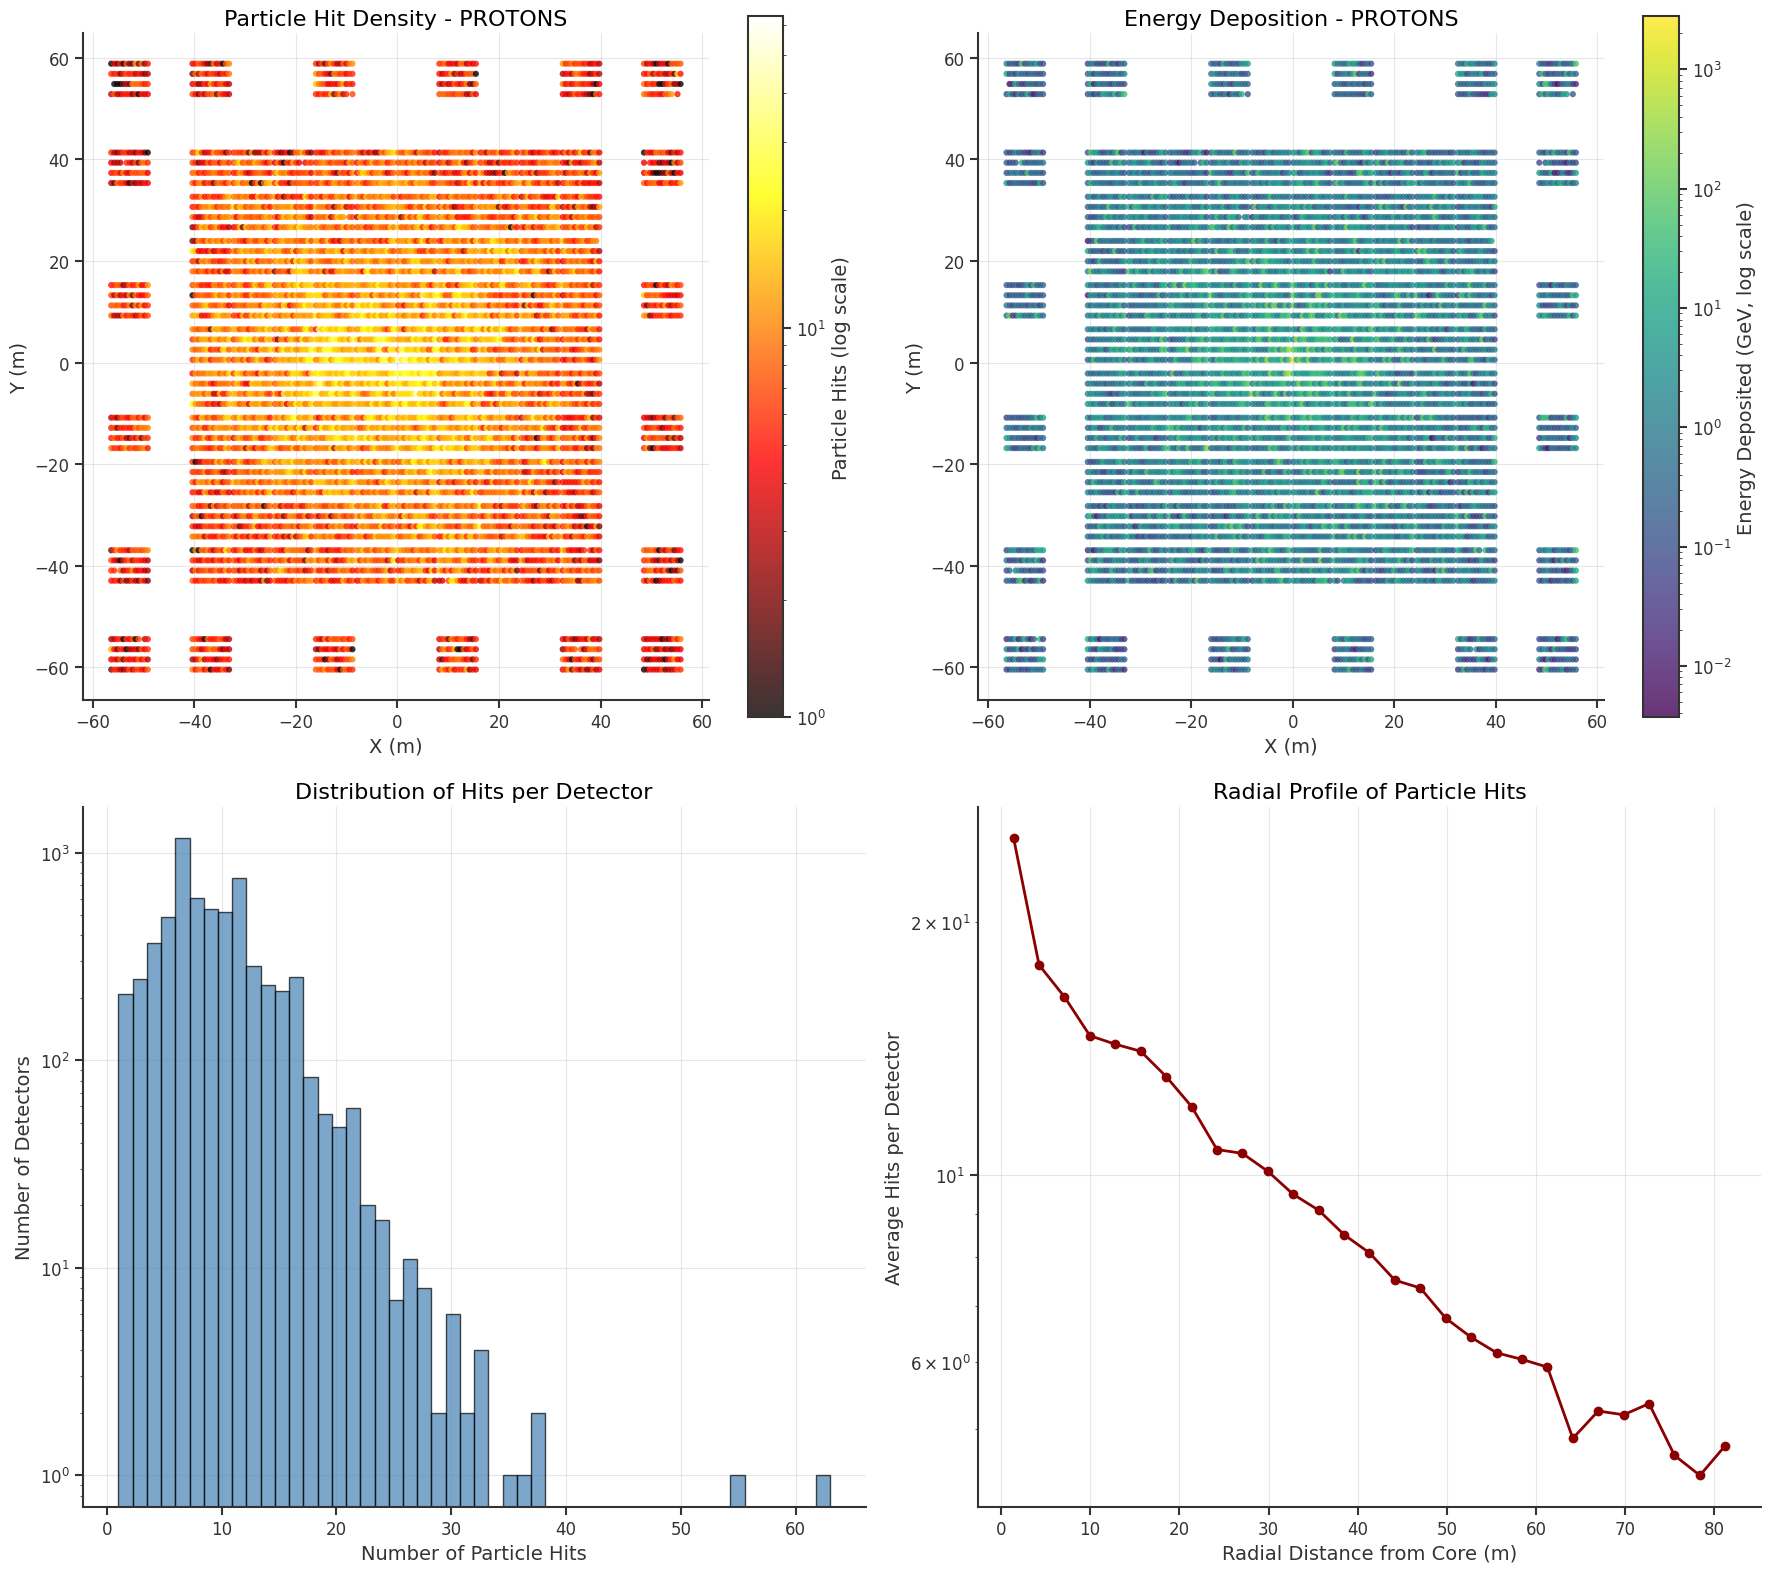

✓ Saved: results/detector_hit_analysis_protons.png

ANALYSIS PLOTS - GAMMAS



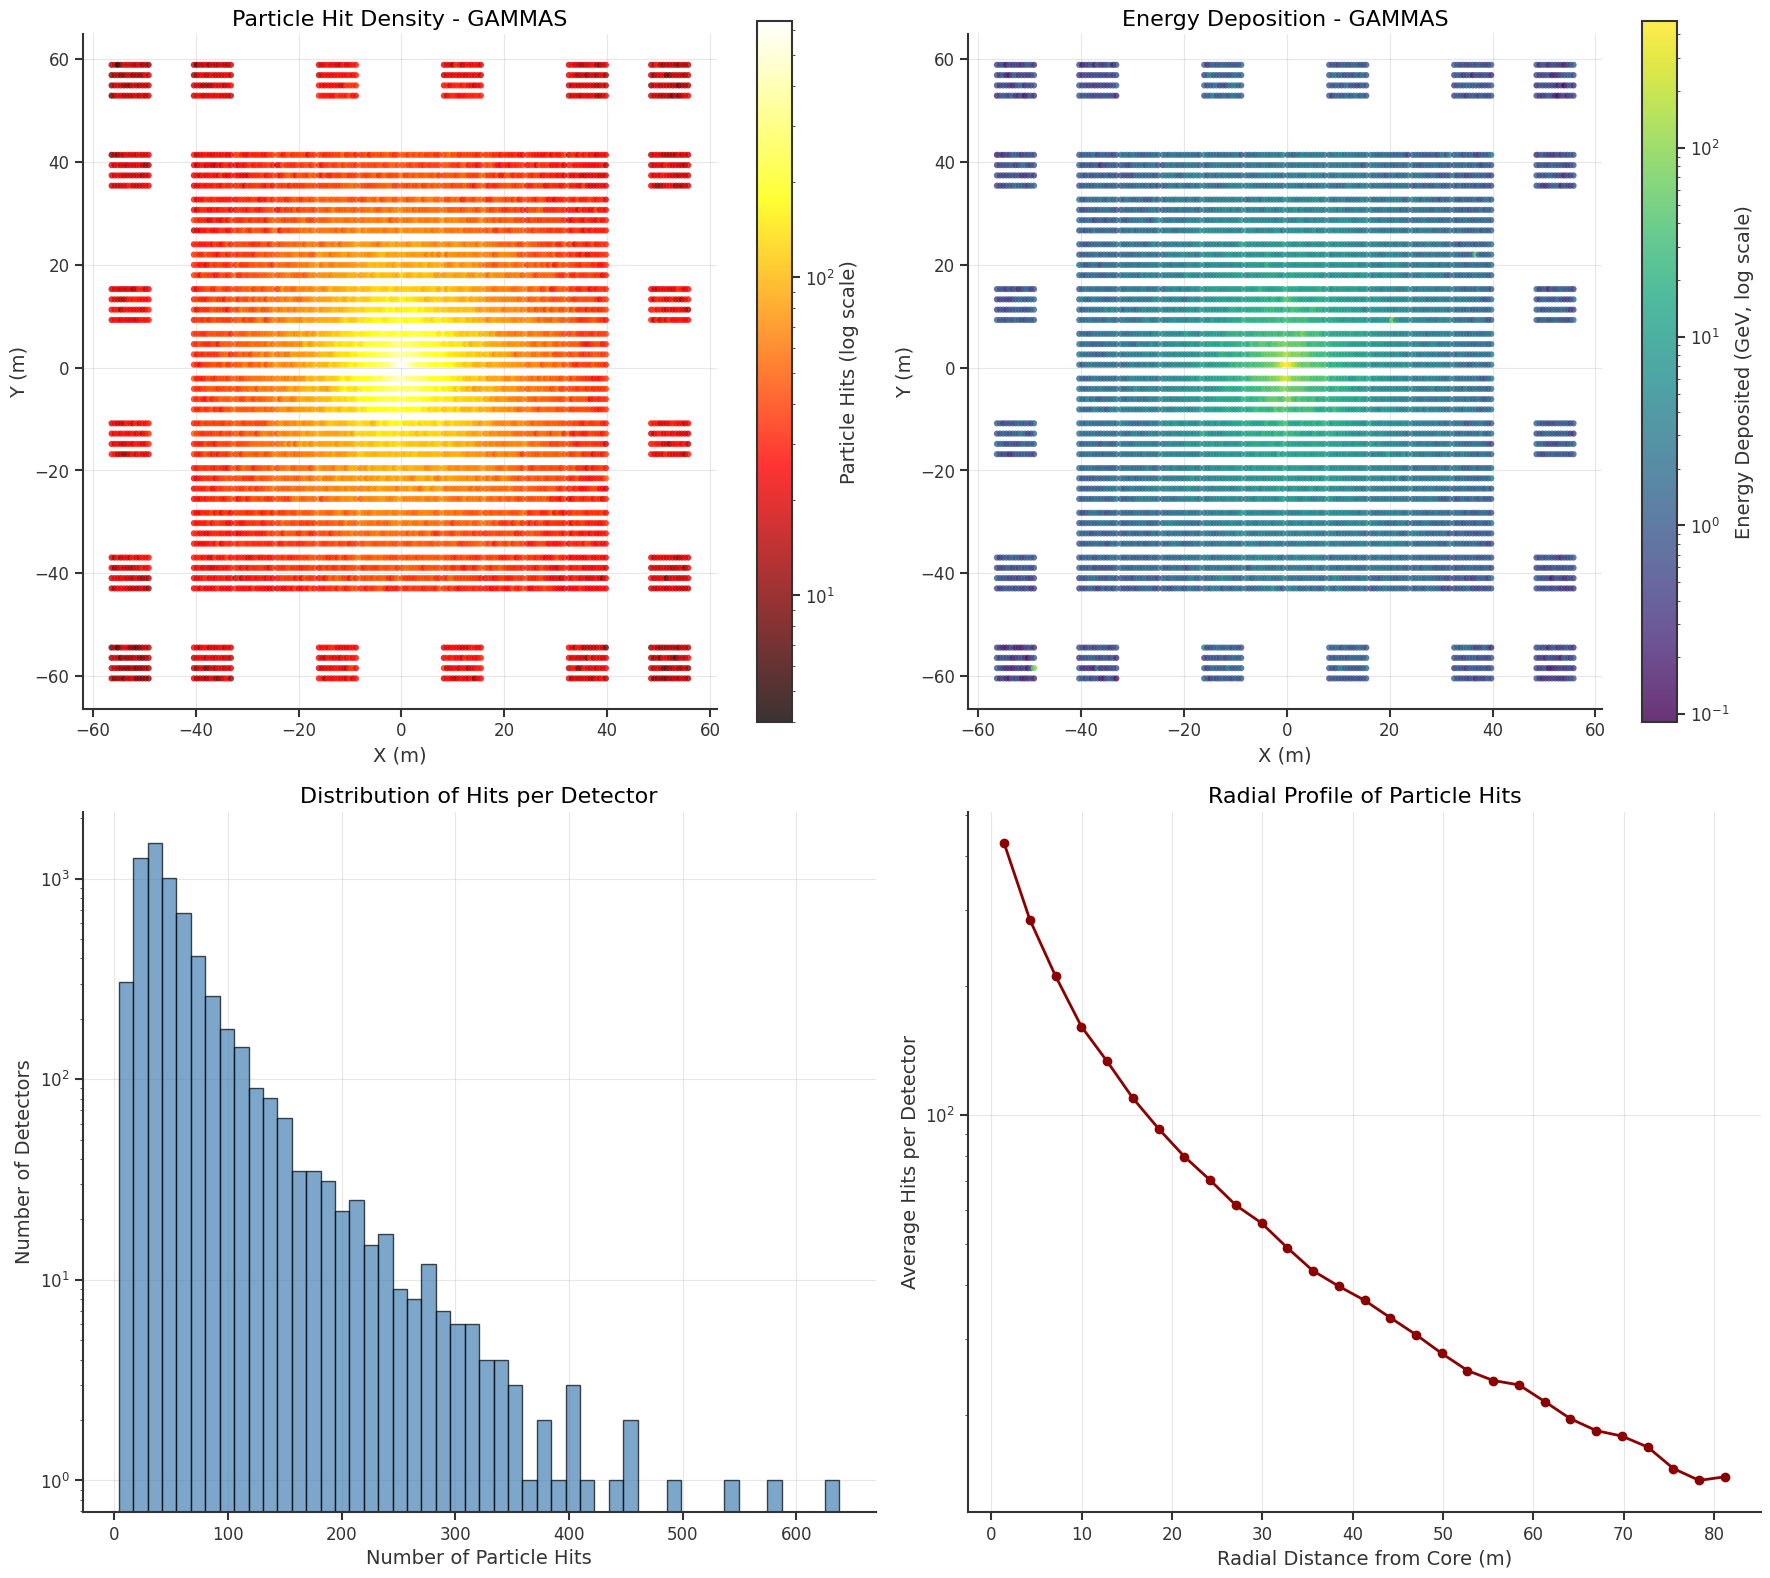

✓ Saved: results/detector_hit_analysis_gammas.png


In [7]:
# Detector Hit Analysis - Process both particle types
for particle_type in particle_types:
    if particle_type not in all_results:
        continue
    
    print(f"\n{'='*70}")
    print(f"ANALYSIS PLOTS - {particle_type.upper()}")
    print(f"{'='*70}\n")
    
    detector_array = all_results[particle_type]['detector_array']
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 16))
    
    hit_detectors = detector_array[detector_array['hit_count'] > 0]
    
    # 1. Particle hit density
    ax = axes[0, 0]
    scatter = ax.scatter(hit_detectors['x_m'], hit_detectors['y_m'],
                        c=hit_detectors['hit_count'], s=20, cmap='hot', 
                        norm=plt.matplotlib.colors.LogNorm(), alpha=0.8, edgecolors='none')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Particle Hits (log scale)')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title(f'Particle Hit Density - {particle_type.upper()}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # 2. Energy deposition
    ax = axes[0, 1]
    energy_detectors = detector_array[detector_array['energy_deposited'] > 0]
    scatter = ax.scatter(energy_detectors['x_m'], energy_detectors['y_m'],
                        c=energy_detectors['energy_deposited'], s=20, cmap='viridis',
                        norm=plt.matplotlib.colors.LogNorm(), alpha=0.8, edgecolors='none')
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Energy Deposited (GeV, log scale)')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title(f'Energy Deposition - {particle_type.upper()}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    # 3. Hit distribution histogram
    ax = axes[1, 0]
    ax.hist(hit_detectors['hit_count'], bins=50, color='steelblue', 
           alpha=0.7, edgecolor='black')
    ax.set_xlabel('Number of Particle Hits')
    ax.set_ylabel('Number of Detectors')
    ax.set_title('Distribution of Hits per Detector')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # 4. Radial profile
    ax = axes[1, 1]
    hit_detectors['r_m'] = np.sqrt(hit_detectors['x_m']**2 + hit_detectors['y_m']**2)
    r_bins = np.linspace(0, hit_detectors['r_m'].max(), 30)
    r_centers = (r_bins[:-1] + r_bins[1:]) / 2
    
    hit_profile = []
    for i in range(len(r_bins)-1):
        mask = (hit_detectors['r_m'] >= r_bins[i]) & (hit_detectors['r_m'] < r_bins[i+1])
        if mask.sum() > 0:
            hit_profile.append(hit_detectors[mask]['hit_count'].mean())
        else:
            hit_profile.append(0)
    
    ax.plot(r_centers, hit_profile, 'o-', color='darkred', linewidth=2, markersize=6)
    ax.set_xlabel('Radial Distance from Core (m)')
    ax.set_ylabel('Average Hits per Detector')
    ax.set_title('Radial Profile of Particle Hits')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(results_dir / f'detector_hit_analysis_{particle_type}.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: {results_dir / f'detector_hit_analysis_{particle_type}.png'}")


GROUND IMPACT VS DETECTOR - PROTONS



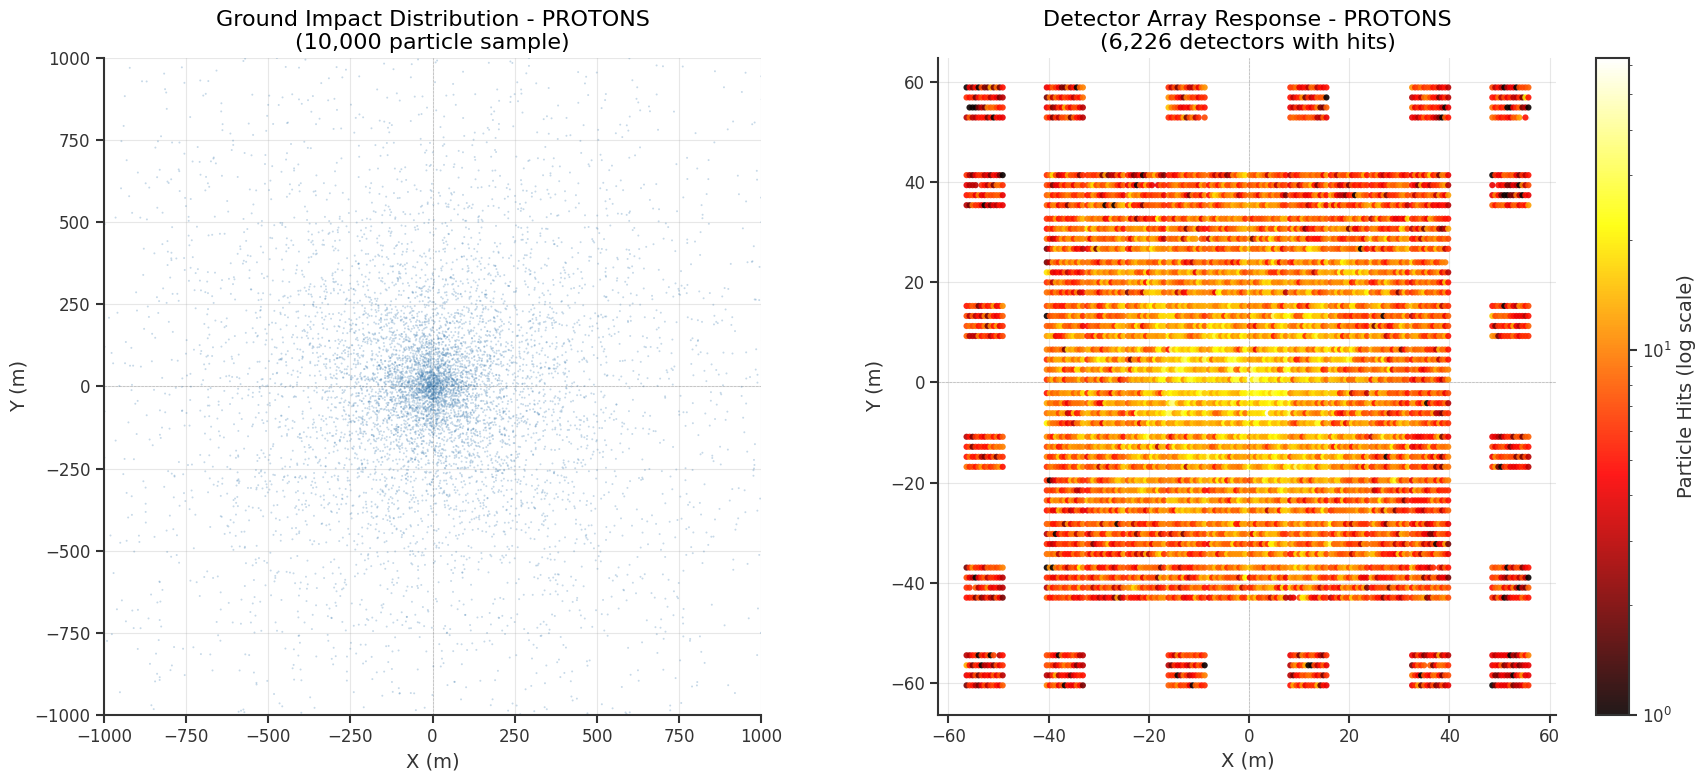

✓ Saved: results/ground_impact_vs_detector_protons.png

GROUND IMPACT VS DETECTOR - GAMMAS



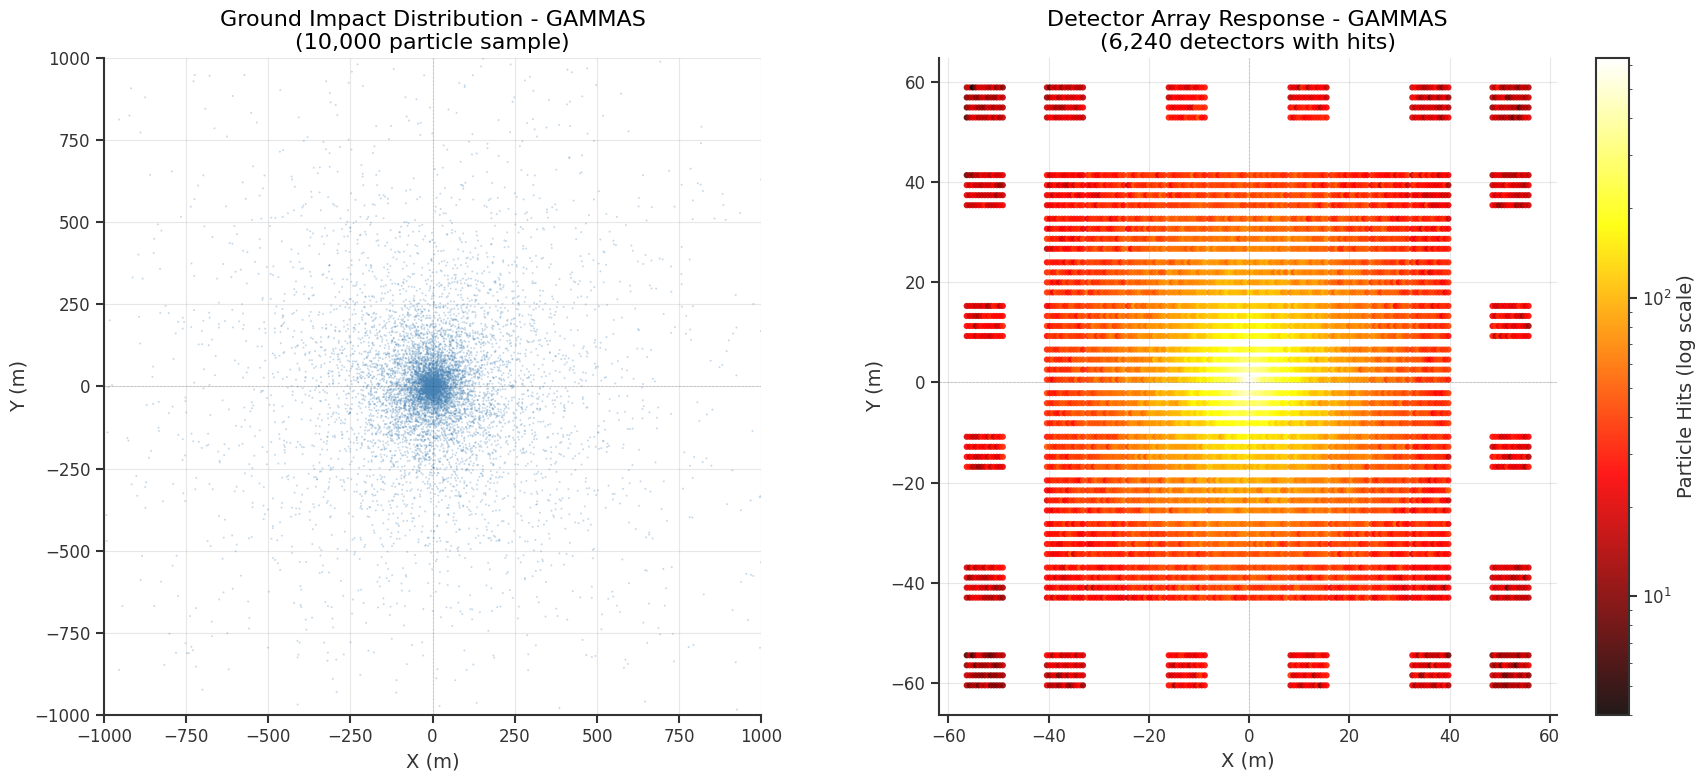

✓ Saved: results/ground_impact_vs_detector_gammas.png


In [8]:
# Ground Impact vs Detector Response - Process both particle types
for particle_type in particle_types:
    if particle_type not in all_results:
        continue
    
    print(f"\n{'='*70}")
    print(f"GROUND IMPACT VS DETECTOR - {particle_type.upper()}")
    print(f"{'='*70}\n")
    
    particles = all_results[particle_type]['particles_mapped']
    detector_array = all_results[particle_type]['detector_array']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Left: Ground impact
    sample_size = min(10000, len(particles))
    sample_idx = np.random.choice(len(particles), sample_size, replace=False)
    sample_particles = particles.iloc[sample_idx]
    
    ax1.scatter(sample_particles['x']/100, sample_particles['y']/100,
               s=2, alpha=0.3, c='steelblue', edgecolors='none')
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Y (m)')
    ax1.set_title(f'Ground Impact Distribution - {particle_type.upper()}\n({sample_size:,} particle sample)')
    ax1.set_aspect('equal')
    ax1.set_xlim(-1000, 1000)
    ax1.set_ylim(-1000, 1000)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.2, linewidth=0.5)
    ax1.axvline(x=0, color='k', linestyle='--', alpha=0.2, linewidth=0.5)
    
    # Right: Detector response
    ax2.scatter(detector_array['x_m'], detector_array['y_m'],
               s=2, c='lightgray', alpha=0.3, label='No hits')
    
    hit_dets = detector_array[detector_array['hit_count'] > 0]
    scatter = ax2.scatter(hit_dets['x_m'], hit_dets['y_m'],
                         c=hit_dets['hit_count'], s=20, cmap='hot',
                         norm=plt.matplotlib.colors.LogNorm(),
                         alpha=0.9, edgecolors='none')
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Particle Hits (log scale)')
    
    ax2.set_xlabel('X (m)')
    ax2.set_ylabel('Y (m)')
    ax2.set_title(f'Detector Array Response - {particle_type.upper()}\n({len(hit_dets):,} detectors with hits)')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.2, linewidth=0.5)
    ax2.axvline(x=0, color='k', linestyle='--', alpha=0.2, linewidth=0.5)
    
    plt.tight_layout()
    fig.savefig(results_dir / f'ground_impact_vs_detector_{particle_type}.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: {results_dir / f'ground_impact_vs_detector_{particle_type}.png'}")


PARTICLE COMPOSITION ANALYSIS


Analyzing PROTONS detected particles...


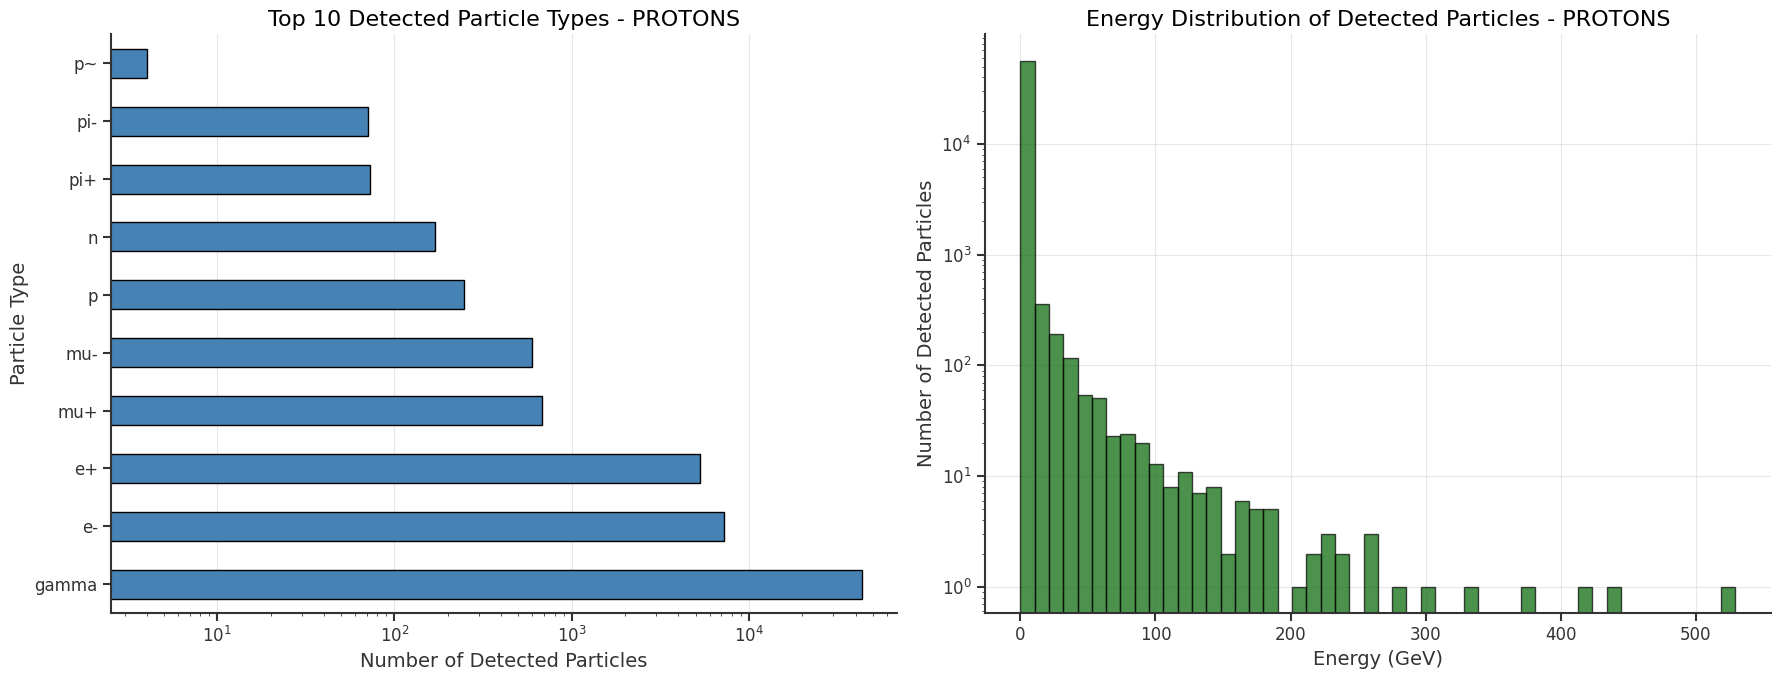

✓ Saved: results/detected_particle_analysis_protons.png

Top 10 detected particle types - PROTONS:
  gamma.........................     43,254 ( 75.1%)
  e-............................      7,201 ( 12.5%)
  e+............................      5,297 (  9.2%)
  mu+...........................        678 (  1.2%)
  mu-...........................        597 (  1.0%)
  p.............................        248 (  0.4%)
  n.............................        170 (  0.3%)
  pi+...........................         73 (  0.1%)
  pi-...........................         71 (  0.1%)
  p~............................          4 (  0.0%)

Analyzing GAMMAS detected particles...


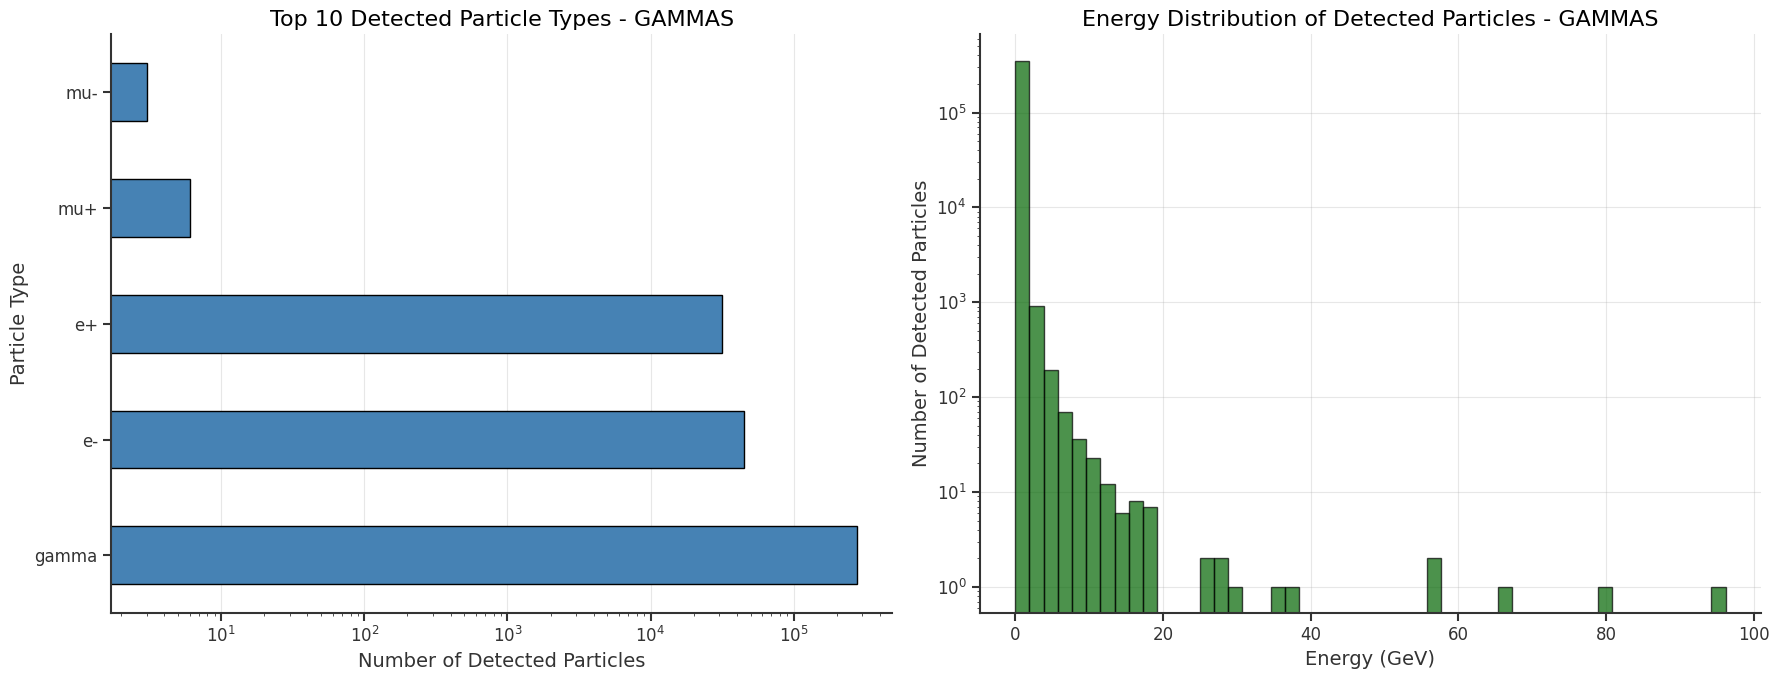

✓ Saved: results/detected_particle_analysis_gammas.png

Top 10 detected particle types - GAMMAS:
  gamma.........................    277,048 ( 78.4%)
  e-............................     44,940 ( 12.7%)
  e+............................     31,496 (  8.9%)
  mu+...........................          6 (  0.0%)
  mu-...........................          3 (  0.0%)


In [9]:
# Particle Type Analysis - Process both particle types
print(f"\n{'='*70}")
print("PARTICLE COMPOSITION ANALYSIS")
print(f"{'='*70}\n")

for particle_type in particle_types:
    if particle_type not in all_results:
        continue
    
    detected_particles = all_results[particle_type]['detected_particles']
    
    print(f"\nAnalyzing {particle_type.upper()} detected particles...")
    
    detected_counts = detected_particles['pdgid'].value_counts().head(10)
    detected_counts.index = detected_counts.index.map(
        lambda pid: Particle.from_pdgid(pid).name if pid != 0 else "unknown"
    )
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Particle type distribution
    detected_counts.plot(kind='barh', ax=ax1, color='steelblue', edgecolor='black')
    ax1.set_xlabel('Number of Detected Particles')
    ax1.set_ylabel('Particle Type')
    ax1.set_title(f'Top 10 Detected Particle Types - {particle_type.upper()}')
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.set_xscale('log')
    
    # Energy distribution
    ax2.hist(detected_particles['energy'], bins=50, 
             color='darkgreen', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Energy (GeV)')
    ax2.set_ylabel('Number of Detected Particles')
    ax2.set_title(f'Energy Distribution of Detected Particles - {particle_type.upper()}')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(results_dir / f'detected_particle_analysis_{particle_type}.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: {results_dir / f'detected_particle_analysis_{particle_type}.png'}")
    
    print(f"\n{'='*70}")
    print(f"Top 10 detected particle types - {particle_type.upper()}:")
    for particle_name, count in detected_counts.items():
        percentage = count / len(detected_particles) * 100
        print(f"  {particle_name:.<30} {count:>10,} ({percentage:>5.1f}%)")
    print(f"{'='*70}")

## 6. Export Results

**Physical Context:**
Exported data files contain:
- **Detector array hits**: Bar-level hit counts and energy deposition for each particle type
- **Detected particles**: Complete particle information for all detected particles (position, energy, type, timing)

These datasets serve as inputs for:
- Shower reconstruction algorithms (core position, direction, energy estimation)
- Machine learning classifiers (gamma/hadron discrimination)
- Detector performance studies (efficiency, acceptance, energy resolution)
- Trigger algorithm development (event selection, background rejection)

In [10]:
# Export data for both particle types
print(f"{'='*70}")
print("EXPORTING RESULTS")
print(f"{'='*70}\n")

for particle_type in particle_types:
    if particle_type not in all_results:
        continue
    
    detector_array = all_results[particle_type]['detector_array']
    detected_particles = all_results[particle_type]['detected_particles']
    
    # Save detector array with hits
    detector_file = results_dir / f'detector_array_hits_{particle_type}.csv'
    detector_array.to_csv(detector_file, index=False)
    print(f"✓ Saved {particle_type} detector data: {detector_file}")
    
    # Save detected particles
    particles_file = results_dir / f'detected_particles_{particle_type}.csv'
    detected_particles.to_csv(particles_file, index=True)
    print(f"✓ Saved {particle_type} detected particles: {particles_file}")
    
    # Print summary statistics
    print(f"\n  {particle_type.upper()} Summary:")
    print(f"    Total bars: {len(detector_array):,}")
    print(f"    Bars with hits: {(detector_array['hit_count'] > 0).sum():,}")
    print(f"    Total particles detected: {len(detected_particles):,}")
    print(f"    Total energy deposited: {detector_array['energy_deposited'].sum():.2e} GeV\n")

print(f"{'='*70}")
print("SIMULATION COMPLETE!")
print(f"All results saved to: {results_dir.resolve()}")
print(f"{'='*70}")

EXPORTING RESULTS

✓ Saved protons detector data: results/detector_array_hits_protons.csv
✓ Saved protons detected particles: results/detected_particles_protons.csv

  PROTONS Summary:
    Total bars: 6,240
    Bars with hits: 6,226
    Total particles detected: 57,600
    Total energy deposited: 5.12e+04 GeV

✓ Saved gammas detector data: results/detector_array_hits_gammas.csv
✓ Saved gammas detected particles: results/detected_particles_gammas.csv

  GAMMAS Summary:
    Total bars: 6,240
    Bars with hits: 6,240
    Total particles detected: 353,493
    Total energy deposited: 3.23e+04 GeV

SIMULATION COMPLETE!
All results saved to: /home/milagros-delgado/Documents/SAPHIR/condor-sim/notebooks/detection/results
